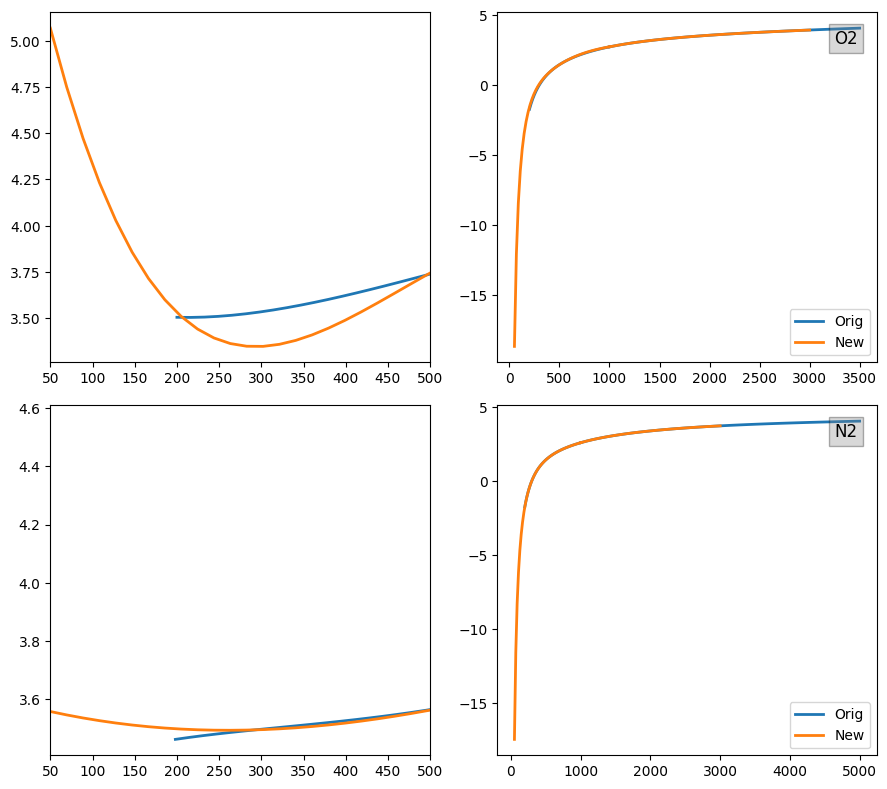

In [1]:
from generateJANAFPolynomials import GenCHEMKINThermo
import matplotlib.pylab as plt


TMin = 50
TMax = 3000
TCommon = 1000

readThermoFile = GenCHEMKINThermo(TMin,TCommon,TMax,1E+5)
readThermoFile.readChemkinFile('test/therm.dat')

thermoFile = GenCHEMKINThermo(TMin,TCommon,TMax,7300)
thermoFile.readChemkinFile('test/therm.dat')
thermoFile.genThermoData(['O2','N2'])
thermoFile.writeThermoFile("therm.dat")


# Count all species generated by the thermo library
species = []
for specie in thermoFile.species:
    if thermoFile.dataFromThermoLib(specie):
        species.append(specie)

# Plot all species that were generated by the thermo library

fig, axs = plt.subplots(len(species),2,figsize=(9, len(species)*4))
axCol0 = axs[:,0]
axCol1 = axs[:,1]
for specie,ax0,ax1 in zip(species,axCol0,axCol1):
    readThermoFile.plot(ax0,specie,"Cp",label="Orig",lw=2)
    thermoFile.plot(ax0,specie,"Cp",label="New",lw=2)
    ax0.set_xlim([TMin,500])

    readThermoFile.plot(ax1,specie,"H",label="Orig",lw=2)
    thermoFile.plot(ax1,specie,"H",label="New",lw=2)

    #ax1.set_xlim([TMin,200])
    ax1.legend()
    ax1.annotate(specie, xy=(0.95, 0.95), xycoords='axes fraction', 
                horizontalalignment='right', verticalalignment='top',fontsize=12,
                bbox=dict(facecolor='gray', edgecolor='k',alpha=0.3))
plt.tight_layout()

